# Lab 4 — Assignment


**Based on:** Lab-4-b (Bernoulli, Binomial, Poisson, Normal, Uniform)


---

### Instructions

1. Run the **Setup** cell first. Do not modify it.
2. There are **10 questions** — two on each distribution. Attempt **all** of them.
3. Every question has three parts:
   - **(a)** and **(b)** — work these out **by hand** and type your working in the *Written answer* cell.
   - **(c)** — write **Python code** in the blank code cell provided and produce the plot asked for.
4. Use `DISCRETE_COLOR` for discrete plots (bars) and `CONTINUOUS_COLOR` for continuous plots (curves).
5. Every plot must have an **x-label, y-label and a title**. Marks are deducted for unlabelled plots.
6. Round all probabilities to **4 decimal places**.
7. Save the notebook with all outputs visible before submitting.

### Marks distribution

| Section | Questions | Marks each | Total |
|---|---|---|---|
| A — Bernoulli | Q1, Q2 | 5 | 10 |
| B — Binomial | Q3, Q4 | 5 | 10 |
| C — Poisson | Q5, Q6 | 5 | 10 |
| D — Normal | Q7, Q8 | 5 | 10 |
| E — Uniform | Q9, Q10 | 5 | 10 |
| | | **Total** | **50** |

### Quick reference — which function do I need?

| Task | `scipy.stats` call |
|---|---|
| $P(X = k)$, discrete | `.pmf(k, ...)` |
| $f(x)$, continuous | `.pdf(x, ...)` |
| $P(X \le x)$ | `.cdf(x, ...)` |
| $P(X > x)$ | `.sf(x, ...)` |
| Value with given $P(X \le x)$ | `.ppf(prob, ...)` |
| Mean / variance | `.mean(...)`, `.var(...)` |
| Random samples | `.rvs(..., size=n, random_state=seed)` |

---

## Setup
Run this cell first — do not change it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from math import comb, factorial, exp, sqrt

DISCRETE_COLOR = "#0E9F9A"     # teal   -> discrete distributions
CONTINUOUS_COLOR = "#E4572E"   # orange -> continuous distributions
HIGHLIGHT_COLOR = "#F4A261"    # use this to highlight a bar or a shaded area

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Setup complete — you are ready to start.")

Setup complete — you are ready to start.


---
# Part A — Bernoulli distribution
*Recall:* $P(X=x) = p^x(1-p)^{1-x}$ for $x \in \{0,1\}$, $\;E[X]=p$, $\;Var(X)=p(1-p)$.

## Q1. The library gate scanner 

> 📚 The RFID gate at the college library reads a student's ID card correctly on the **first tap 92%** of the time. One student taps her card once.
>
> Let $X = 1$ if the card is read on the first tap, and $X = 0$ if it is not.
>
> **(a)** State the value of $p$ and find $P(X=1)$ and $P(X=0)$.
> **(b)** Find the mean and the variance of $X$, showing the substitution into the formulas.
> **(c)** Write Python code that:
> - builds the PMF of $X$ using `stats.bernoulli.pmf`,
> - draws a **bar chart** of the distribution in `DISCRETE_COLOR` with the ticks labelled `"Not read (0)"` and `"Read (1)"`,
> - writes the probability value on top of each bar,
> - prints the mean and the variance obtained from `scipy`, and checks that they match your hand answers in (b).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)** A "success" is the card being read on the first tap, so $p = 0.92$.
>
> $P(X=1) = p^1(1-p)^0 = 0.92$
>
> $P(X=0) = p^0(1-p)^1 = 1 - 0.92 = 0.08$
>
> **(b)** $E[X] = p = 0.92$
>
> $Var(X) = p(1-p) = 0.92 \times 0.08 = 0.0736$


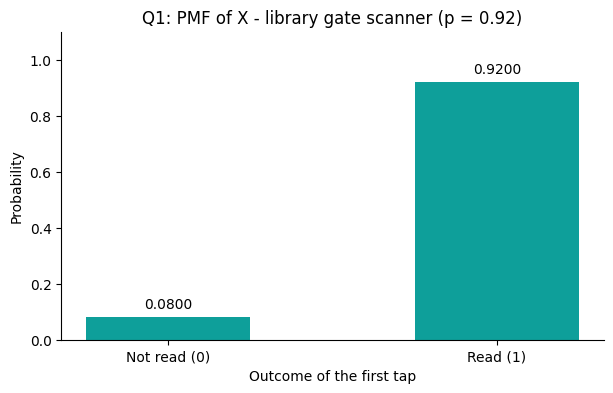

Mean     (scipy) = 0.9200   | hand answer = 0.9200
Variance (scipy) = 0.0736   | hand answer = 0.0736
Matches hand answers: True


In [2]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
p = 0.92
x = np.array([0, 1])
pmf = stats.bernoulli.pmf(x, p)

fig, ax = plt.subplots()
ax.bar(x, pmf, color=DISCRETE_COLOR, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels(["Not read (0)", "Read (1)"])
for xi, pi in zip(x, pmf):
    ax.text(xi, pi + 0.02, f"{pi:.4f}", ha="center", va="bottom")
ax.set_ylim(0, 1.1)
ax.set_xlabel("Outcome of the first tap")
ax.set_ylabel("Probability")
ax.set_title("Q1: PMF of X - library gate scanner (p = 0.92)")
plt.show()

mean_sp = stats.bernoulli.mean(p)
var_sp = stats.bernoulli.var(p)
print(f"Mean     (scipy) = {mean_sp:.4f}   | hand answer = 0.9200")
print(f"Variance (scipy) = {var_sp:.4f}   | hand answer = 0.0736")
print("Matches hand answers:", bool(np.isclose(mean_sp, 0.92) and np.isclose(var_sp, 0.0736)))

# ------------------------------------------------------------

## Q2. Estimating $p$ from attendance data &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 👆 A biometric attendance device records whether a student's fingerprint is accepted on the **first attempt**. Over one semester the device logged **2,000 scans**, of which **1,740** were accepted on the first attempt. Treat one scan as a single Bernoulli trial with $X=1$ for *accepted*.
>
> **(a)** Estimate $p$ from the data and write down the full PMF $P(X=x)$ with the estimated value substituted in.
> **(b)** Find the mean and variance. Then answer: for what value of $p$ would the variance of a Bernoulli variable be the **largest possible**, and what is that largest value? Justify your answer using the formula $Var(X)=p(1-p)$.
> **(c)** Write Python code that:
> - simulates 2,000 Bernoulli trials with your estimated $p$ using `stats.bernoulli.rvs(..., random_state=42)`,
> - prints the **simulated proportion** of successes next to the theoretical $p$,
> - plots the **theoretical PMF and the simulated relative frequencies side by side** as grouped bars with a legend,
> - plots $Var(X)=p(1-p)$ against $p$ for $p$ from 0 to 1 in a **second figure**, and marks the maximum point with a marker and an annotation.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)** $\hat{p} = \dfrac{\text{accepted}}{\text{total}} = \dfrac{1740}{2000} = 0.87$
>
> PMF: $P(X=x) = 0.87^{x}\,(0.13)^{1-x}$ for $x \in \{0,1\}$, i.e. $P(X=1)=0.87$ and $P(X=0)=0.13$.
>
> **(b)** $E[X] = p = 0.87$
>
> $Var(X) = p(1-p) = 0.87 \times 0.13 = 0.1131$
>
> **Largest possible variance:** $Var(X) = p(1-p) = p - p^2 = \dfrac14 - \left(p-\dfrac12\right)^2$. The squared term is never negative, so $Var(X) \le \dfrac14$, with equality exactly when $p = \dfrac12$. (Check with calculus: $\dfrac{d}{dp}(p-p^2) = 1-2p = 0 \Rightarrow p=\dfrac12$, and the second derivative $-2<0$, so it is a maximum.)
>
> So the variance is largest at $p = 0.5$, and the maximum value is $0.5 \times 0.5 = 0.25$. Intuitively, a fair coin is the most "unpredictable" Bernoulli variable.


Theoretical p        = 0.8700
Simulated proportion = 0.8675


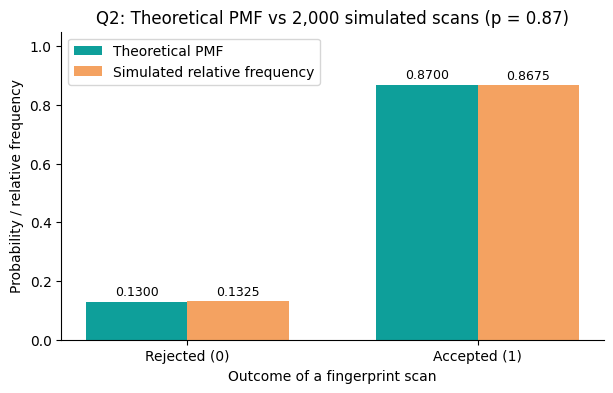

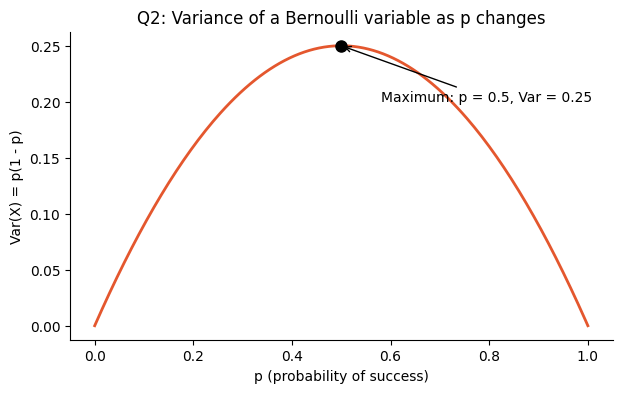

In [3]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
# ---- Figure 1: theoretical PMF vs simulated relative frequencies ----
n_scans, n_accepted = 2000, 1740
p_hat = n_accepted / n_scans

sim = stats.bernoulli.rvs(p_hat, size=2000, random_state=42)
print(f"Theoretical p        = {p_hat:.4f}")
print(f"Simulated proportion = {sim.mean():.4f}")

x = np.array([0, 1])
theory = stats.bernoulli.pmf(x, p_hat)
sim_freq = np.array([(sim == 0).mean(), (sim == 1).mean()])

w = 0.35
fig, ax = plt.subplots()
b1 = ax.bar(x - w/2, theory, width=w, color=DISCRETE_COLOR, label="Theoretical PMF")
b2 = ax.bar(x + w/2, sim_freq, width=w, color=HIGHLIGHT_COLOR, label="Simulated relative frequency")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(["Rejected (0)", "Accepted (1)"])
ax.set_ylim(0, 1.05)
ax.set_xlabel("Outcome of a fingerprint scan")
ax.set_ylabel("Probability / relative frequency")
ax.set_title("Q2: Theoretical PMF vs 2,000 simulated scans (p = 0.87)")
ax.legend()
plt.show()

# ---- Figure 2: Var(X) = p(1-p) against p ----
p_grid = np.linspace(0, 1, 201)
var_grid = p_grid * (1 - p_grid)

fig, ax = plt.subplots()
ax.plot(p_grid, var_grid, color=CONTINUOUS_COLOR, linewidth=2)
ax.plot(0.5, 0.25, "o", color="black", markersize=8)
ax.annotate("Maximum: p = 0.5, Var = 0.25", xy=(0.5, 0.25), xytext=(0.58, 0.20),
            arrowprops=dict(arrowstyle="->"))
ax.set_xlabel("p (probability of success)")
ax.set_ylabel("Var(X) = p(1 - p)")
ax.set_title("Q2: Variance of a Bernoulli variable as p changes")
plt.show()

# ------------------------------------------------------------

---
# Part B — Binomial distribution
*Recall:* $P(X=k) = \binom{n}{k}p^k(1-p)^{n-k}$, $\;E[X]=np$, $\;Var(X)=np(1-p)$.

## Q3. Guessing a multiple-choice quiz &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📝 An online quiz has **12 multiple-choice questions**, each with **4 options** and exactly one correct answer. A student who has not studied guesses every answer at random. Let $X$ = number of questions answered correctly.
>
> **(a)** State $n$ and $p$, check that the **BINS** conditions hold, and compute $P(X=5)$ **by hand**, showing the value of $\binom{12}{5}$.
> **(b)** Find the mean and the variance of $X$.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
>

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)** $n = 12$ questions and $p = \dfrac14 = 0.25$ (one correct option out of 4).
>
> **BINS check:** **B**inary - each answer is either correct or incorrect. **I**ndependent - random guesses on different questions do not affect each other. **N**umber of trials is fixed - $n = 12$. **S**ame probability - $p = 0.25$ on every question. All four hold, so $X \sim \text{Binomial}(12, 0.25)$.
>
> $\dbinom{12}{5} = \dfrac{12!}{5!\,7!} = \dfrac{12\times11\times10\times9\times8}{5\times4\times3\times2\times1} = \dfrac{95040}{120} = 792$
>
> $P(X=5) = 792 \times (0.25)^5 \times (0.75)^7 = 792 \times 0.0009766 \times 0.1334839 \approx 0.1032$
>
> **(b)** $E[X] = np = 12 \times 0.25 = 3$
>
> $Var(X) = np(1-p) = 12 \times 0.25 \times 0.75 = 2.25$


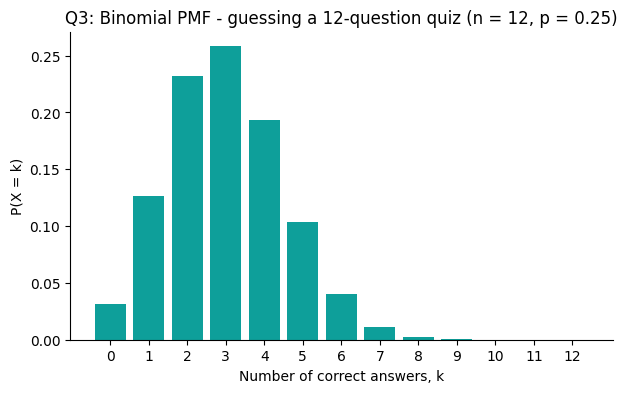

P(X = 5)    = 0.1032
Mean        = 3.0000
Variance    = 2.2500


In [4]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
n, p = 12, 0.25
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

fig, ax = plt.subplots()
ax.bar(k, pmf, color=DISCRETE_COLOR)
ax.set_xticks(k)
ax.set_xlabel("Number of correct answers, k")
ax.set_ylabel("P(X = k)")
ax.set_title("Q3: Binomial PMF - guessing a 12-question quiz (n = 12, p = 0.25)")
plt.show()

print(f"P(X = 5)    = {stats.binom.pmf(5, n, p):.4f}")
print(f"Mean        = {stats.binom.mean(n, p):.4f}")
print(f"Variance    = {stats.binom.var(n, p):.4f}")

# ------------------------------------------------------------

#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> 
> 
> 
> 
> 


---
# Part C — Poisson distribution
*Recall:* $P(X=k) = \dfrac{\lambda^k e^{-\lambda}}{k!}$, $\;E[X]=Var(X)=\lambda$.

## Q5. Help-desk emails &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 📧 The IT help-desk of a college receives on average **3 emails per hour**. Let $X$ = number of emails received in one hour.
>
> **(a)** Compute $P(X = 0)$ and $P(X = 2)$ **by hand**, showing the substitution into the formula ($e^{-3} \approx 0.0498$).
> **(b)** State the mean and the variance, and explain in one line what is special about them for a Poisson distribution.
> **(c)** Write Python code that:
> - plots the PMF as a bar chart for $k = 0$ to $12$ in `DISCRETE_COLOR`,
> - prints $P(X=0)$, $P(X=2)$ and $P(X \le 5)$,
> - prints the smallest value of $k$ for which $P(X \le k) \ge 0.95$ (use `.ppf` or a loop).

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)** $\lambda = 3$.
>
> $P(X=0) = \dfrac{3^0 e^{-3}}{0!} = e^{-3} \approx 0.0498$
>
> $P(X=2) = \dfrac{3^2 e^{-3}}{2!} = \dfrac{9 \times 0.049787}{2} = 4.5 \times 0.049787 \approx 0.2240$ (using the rounded $0.0498$ gives $0.2241$; the extra digit avoids the rounding error).
>
> **(b)** $E[X] = \lambda = 3$ and $Var(X) = \lambda = 3$.
>
> What is special: for a Poisson distribution the **mean and the variance are equal** (both equal $\lambda$).


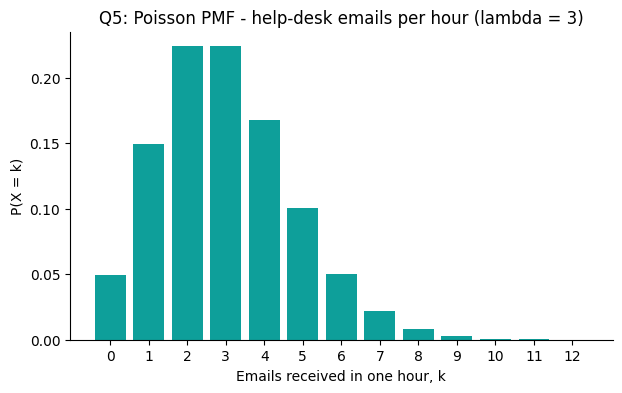

P(X = 0)  = 0.0498
P(X = 2)  = 0.2240
P(X <= 5) = 0.9161
Smallest k with P(X <= k) >= 0.95: k = 6
  check: P(X <= 5) = 0.9161, P(X <= 6) = 0.9665


In [5]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
lam = 3
k = np.arange(0, 13)
pmf = stats.poisson.pmf(k, lam)

fig, ax = plt.subplots()
ax.bar(k, pmf, color=DISCRETE_COLOR)
ax.set_xticks(k)
ax.set_xlabel("Emails received in one hour, k")
ax.set_ylabel("P(X = k)")
ax.set_title("Q5: Poisson PMF - help-desk emails per hour (lambda = 3)")
plt.show()

print(f"P(X = 0)  = {stats.poisson.pmf(0, lam):.4f}")
print(f"P(X = 2)  = {stats.poisson.pmf(2, lam):.4f}")
print(f"P(X <= 5) = {stats.poisson.cdf(5, lam):.4f}")

k95 = int(stats.poisson.ppf(0.95, lam))
print(f"Smallest k with P(X <= k) >= 0.95: k = {k95}")
print(f"  check: P(X <= {k95 - 1}) = {stats.poisson.cdf(k95 - 1, lam):.4f}, P(X <= {k95}) = {stats.poisson.cdf(k95, lam):.4f}")

# ------------------------------------------------------------

## Q6. Server errors over a night shift &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> 🖥️ A web server logs errors at an average rate of **1.5 errors per hour**. The night shift runs from 10 pm to 6 am, i.e. **8 hours**.
>
> **(a)** Find the value of $\lambda$ for the **whole 8-hour shift**, and compute by hand the probability of a **clean shift** (zero errors in the 8 hours).
> **(b)** State the mean and variance for the 8-hour window. The on-call engineer is paged if **more than 18 errors** occur in the shift — write the expression for that probability and name the `scipy` function that gives it directly.
> **(c)** Write Python code that:
> - creates **two subplots side by side** — the PMF for the 1-hour window ($\lambda = 1.5$) and the PMF for the 8-hour window — each with its own sensible range of $k$, title and labels,


#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> **(a)** Rate per hour = 1.5, shift length = 8 hours, so $\lambda = 1.5 \times 8 = 12$.
>
> Clean shift: $P(X=0) = \dfrac{12^0 e^{-12}}{0!} = e^{-12} \approx 6.14 \times 10^{-6} \approx 0.0000$ (to 4 d.p.) - a completely error-free night is extremely unlikely.
>
> **(b)** For the 8-hour window: $E[X] = \lambda = 12$ and $Var(X) = \lambda = 12$.
>
> The engineer is paged if more than 18 errors occur: $P(X>18) = 1 - P(X \le 18) = 1 - \displaystyle\sum_{k=0}^{18}\dfrac{e^{-12}\,12^k}{k!}$.
>
> `scipy` gives this directly with the survival function: `stats.poisson.sf(18, 12)` (equal to `1 - stats.poisson.cdf(18, 12)`). Its value is about $0.0374$.


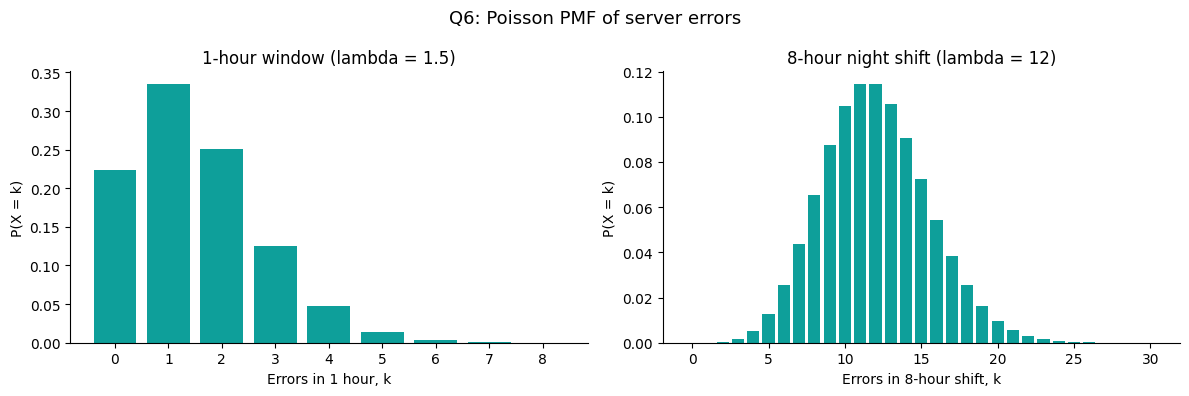

lambda for the shift       = 12.0
P(clean shift) = P(X = 0)  = 0.0000  (exact: 6.144e-06)
P(paged) = P(X > 18)       = 0.0374


In [6]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
lam_1h = 1.5
lam_8h = 1.5 * 8

k1 = np.arange(0, 9)      # 1-hour window: probabilities are negligible beyond ~8
k8 = np.arange(0, 31)     # 8-hour window: centred around 12

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(k1, stats.poisson.pmf(k1, lam_1h), color=DISCRETE_COLOR)
axes[0].set_xticks(k1)
axes[0].set_xlabel("Errors in 1 hour, k")
axes[0].set_ylabel("P(X = k)")
axes[0].set_title("1-hour window (lambda = 1.5)")

axes[1].bar(k8, stats.poisson.pmf(k8, lam_8h), color=DISCRETE_COLOR)
axes[1].set_xlabel("Errors in 8-hour shift, k")
axes[1].set_ylabel("P(X = k)")
axes[1].set_title("8-hour night shift (lambda = 12)")

fig.suptitle("Q6: Poisson PMF of server errors", fontsize=13)
plt.tight_layout()
plt.show()

print(f"lambda for the shift       = {lam_8h}")
print(f"P(clean shift) = P(X = 0)  = {stats.poisson.pmf(0, lam_8h):.4f}  (exact: {stats.poisson.pmf(0, lam_8h):.3e})")
print(f"P(paged) = P(X > 18)       = {stats.poisson.sf(18, lam_8h):.4f}")

# ------------------------------------------------------------

---
# Part D — Normal distribution
*Recall:* $f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}e^{-(x-\mu)^2/2\sigma^2}$, $\;Z=\dfrac{X-\mu}{\sigma}$, $\;E[X]=\mu$, $\;Var(X)=\sigma^2$.

## Q7. Battery life of a phone &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🔋 The battery life of a phone model is normally distributed with a mean of **18 hours** and a standard deviation of **1.5 hours**. Let $X$ = battery life of a randomly chosen phone.
>
> **(a)** Compute the **Z-score** for a battery life of 15 hours and say in words what that Z-score means.
> **(b)** Using the 68–95–99.7 rule, state the interval of battery lives that contains about **95%** of the phones. Show how you obtained it.
> **(c)** Write Python code that:
> - generates 400 equally spaced values of $x$ over $\mu \pm 4\sigma$ and computes the PDF,
> - plots the curve in `CONTINUOUS_COLOR` with a title and axis labels,
.

#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)** $\mu = 18$, $\sigma = 1.5$, $x = 15$.
>
> $Z = \dfrac{x-\mu}{\sigma} = \dfrac{15-18}{1.5} = -2$
>
> Meaning: a battery life of 15 hours is **2 standard deviations below the mean** - it is an unusually short-lived phone.
>
> **(b)** By the 68-95-99.7 rule, about 95% of values lie within 2 standard deviations of the mean: $\mu \pm 2\sigma = 18 \pm 2(1.5) = 18 \pm 3$.
>
> So about 95% of phones have a battery life between **15 hours and 21 hours**.


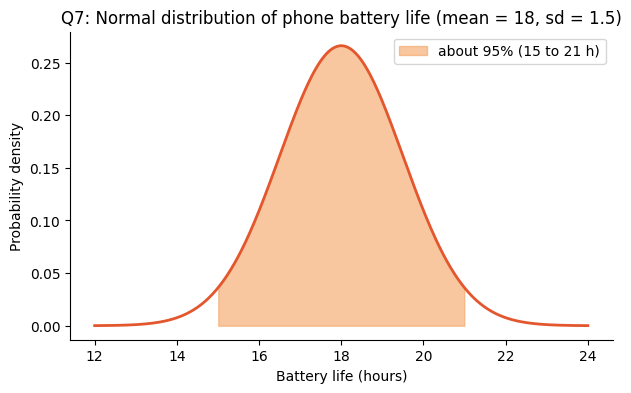

Z-score for 15 hours              = -2.0000
P(15 <= X <= 21) from scipy       = 0.9545


In [7]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu, sigma = 18, 1.5
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots()
ax.plot(x, pdf, color=CONTINUOUS_COLOR, linewidth=2)

# shade the central ~95% region: mu +/- 2 sigma = 15 to 21 hours
mask = (x >= 15) & (x <= 21)
ax.fill_between(x[mask], pdf[mask], color=HIGHLIGHT_COLOR, alpha=0.6, label="about 95% (15 to 21 h)")

ax.set_xlabel("Battery life (hours)")
ax.set_ylabel("Probability density")
ax.set_title("Q7: Normal distribution of phone battery life (mean = 18, sd = 1.5)")
ax.legend()
plt.show()

print(f"Z-score for 15 hours              = {(15 - mu) / sigma:.4f}")
print(f"P(15 <= X <= 21) from scipy       = {stats.norm.cdf(21, mu, sigma) - stats.norm.cdf(15, mu, sigma):.4f}")

# ------------------------------------------------------------

## Q8. Calibrating a coffee machine &nbsp;&nbsp;<sub>[5 marks] — *harder*</sub>

> ☕ A vending machine fills cups with coffee. The fill volume is normally distributed with a mean of **200 ml**, but the standard deviation is **not known**. The service log shows that **2.5% of cups overflow**, which happens whenever the fill exceeds **210 ml**.
>
> **(a)** Using the standard normal value $z_{0.975} \approx 1.96$, find the standard deviation $\sigma$ of the fill volume. Show the working.
> **(b)** With that $\sigma$, find the volume below which only **1%** of cups fall (the 1st percentile), and state which `scipy` function gives it. A customer complains if the cup holds less than **190 ml** — write the expression for that probability.
> **(c)** Write Python code that:
> - computes $\sigma$ using `stats.norm.ppf` rather than the rounded 1.96,
> - plots the PDF over a sensible range in `CONTINUOUS_COLOR`,



#### ✍️ Written answer (a), (b) and (d) — *type your hand calculation below*

> **(a)** $X \sim N(200, \sigma^2)$ and $P(X > 210) = 0.025$, so $P(X \le 210) = 0.975$.
>
> The Z-value with $0.975$ to its left is $z_{0.975} \approx 1.96$, so $\dfrac{210-200}{\sigma} = 1.96$.
>
> $\sigma = \dfrac{10}{1.96} \approx 5.10$ ml.
>
> **(b)** The 1st percentile has $z_{0.01} \approx -2.326$, so $x = \mu + z\sigma = 200 + (-2.326)(5.102) \approx 188.13$ ml. Only 1% of cups hold less than about **188.1 ml**. In `scipy`: `stats.norm.ppf(0.01, loc=200, scale=sigma)`.
>
> Complaint probability: $P(X < 190) = P\!\left(Z < \dfrac{190-200}{5.102}\right) = P(Z < -1.96) \approx 0.0250$, which in `scipy` is `stats.norm.cdf(190, loc=200, scale=sigma)`. (It equals the overflow probability because 190 and 210 are symmetric about the mean.)


z_0.975 (scipy) = 1.9600
sigma           = 5.1021 ml


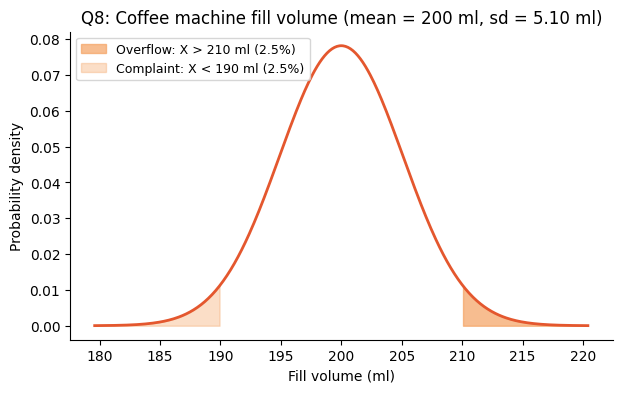

1st percentile        = 188.13 ml
P(X < 190)            = 0.0250
P(X > 210)            = 0.0250


In [8]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
mu = 200
# sigma from the overflow condition P(X > 210) = 0.025, using ppf instead of the rounded 1.96
z = stats.norm.ppf(0.975)
sigma = (210 - mu) / z
print(f"z_0.975 (scipy) = {z:.4f}")
print(f"sigma           = {sigma:.4f} ml")

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots()
ax.plot(x, pdf, color=CONTINUOUS_COLOR, linewidth=2)
hi = x >= 210
lo = x <= 190
ax.fill_between(x[hi], pdf[hi], color=HIGHLIGHT_COLOR, alpha=0.7, label="Overflow: X > 210 ml (2.5%)")
ax.fill_between(x[lo], pdf[lo], color=HIGHLIGHT_COLOR, alpha=0.35, label="Complaint: X < 190 ml (2.5%)")
ax.set_xlabel("Fill volume (ml)")
ax.set_ylabel("Probability density")
ax.set_title("Q8: Coffee machine fill volume (mean = 200 ml, sd = 5.10 ml)")
ax.legend(loc="upper left", fontsize=9)
plt.show()

print(f"1st percentile        = {stats.norm.ppf(0.01, loc=mu, scale=sigma):.2f} ml")
print(f"P(X < 190)            = {stats.norm.cdf(190, loc=mu, scale=sigma):.4f}")
print(f"P(X > 210)            = {stats.norm.sf(210, loc=mu, scale=sigma):.4f}")

# ------------------------------------------------------------

---
# Part E — Uniform distribution
*Recall:* $f(x)=\dfrac{1}{b-a}$ for $a \le x \le b$, $\;P(c \le X \le d)=\dfrac{d-c}{b-a}$, $\;E[X]=\dfrac{a+b}{2}$, $\;Var(X)=\dfrac{(b-a)^2}{12}$.

⚠️ **Note on `scipy`:** for a uniform distribution on $[a, b]$ you must use `loc=a` and `scale=b-a`, **not** `loc=a, scale=b`.

## Q9. Waiting for the campus shuttle &nbsp;&nbsp;<sub>[5 marks] — *straightforward*</sub>

> 🚌 The campus shuttle leaves the gate exactly every **15 minutes**. A student walks up to the stop at a completely random moment, so her waiting time $X$ is uniformly distributed between **0 and 15 minutes**.
>

> **(a)** Find the mean waiting time and the variance, showing the substitution.
> **(b)** Write Python code that:
> - plots the PDF as a flat line/rectangle over $[0, 15]$ in `CONTINUOUS_COLOR` (extend the x-axis a little beyond the range so the flat top is clear),


#### ✍️ Written answer (a) and (b) — *type your hand calculation below*

> **(a)** $X \sim U(a=0,\ b=15)$.
>
> $E[X] = \dfrac{a+b}{2} = \dfrac{0+15}{2} = 7.5$ minutes
>
> $Var(X) = \dfrac{(b-a)^2}{12} = \dfrac{(15-0)^2}{12} = \dfrac{225}{12} = 18.75$ minutes$^2$
>
> **(b)** The plot is made in the code cell below. The PDF is a flat line of height $f(x) = \dfrac{1}{b-a} = \dfrac{1}{15} \approx 0.0667$ on $[0, 15]$ and $0$ elsewhere (total area $= 15 \times \tfrac{1}{15} = 1$).


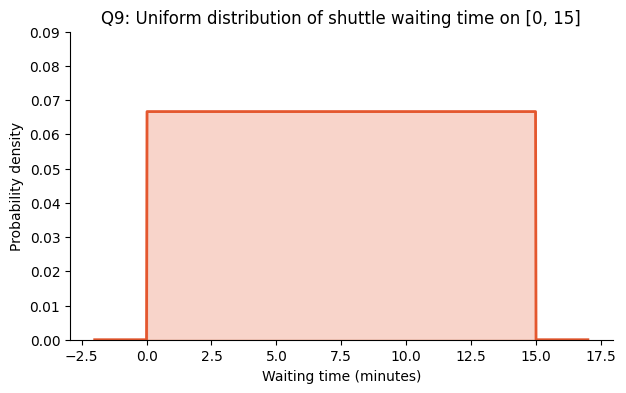

Height of the PDF     = 0.0667
Mean     (scipy)      = 7.5000
Variance (scipy)      = 18.7500


In [9]:
# ✏️ WRITE YOUR CODE HERE
# ------------------------------------------------------------
a, b = 0, 15
x = np.linspace(-2, 17, 1000)                 # a little beyond [0, 15] so the flat top is clear
pdf = stats.uniform.pdf(x, loc=a, scale=b - a)   # scale = b - a, NOT b

fig, ax = plt.subplots()
ax.plot(x, pdf, color=CONTINUOUS_COLOR, linewidth=2)
inside = (x >= a) & (x <= b)
ax.fill_between(x[inside], pdf[inside], color=CONTINUOUS_COLOR, alpha=0.25)
ax.set_ylim(0, 0.09)
ax.set_xlabel("Waiting time (minutes)")
ax.set_ylabel("Probability density")
ax.set_title("Q9: Uniform distribution of shuttle waiting time on [0, 15]")
plt.show()

print(f"Height of the PDF     = {1/(b - a):.4f}")
print(f"Mean     (scipy)      = {stats.uniform.mean(loc=a, scale=b - a):.4f}")
print(f"Variance (scipy)      = {stats.uniform.var(loc=a, scale=b - a):.4f}")

# ------------------------------------------------------------